In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# LOAD DATA
df=pd.read_csv("iris.csv")
print(df.head())
print(df.info())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [7]:
# Descriptive analysis
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [9]:
print(df.groupby('species').mean().round(2))
#It helps to know that the virginica has the largest petals and the setosa has the smallest one out there

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.42          1.46         0.24
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03


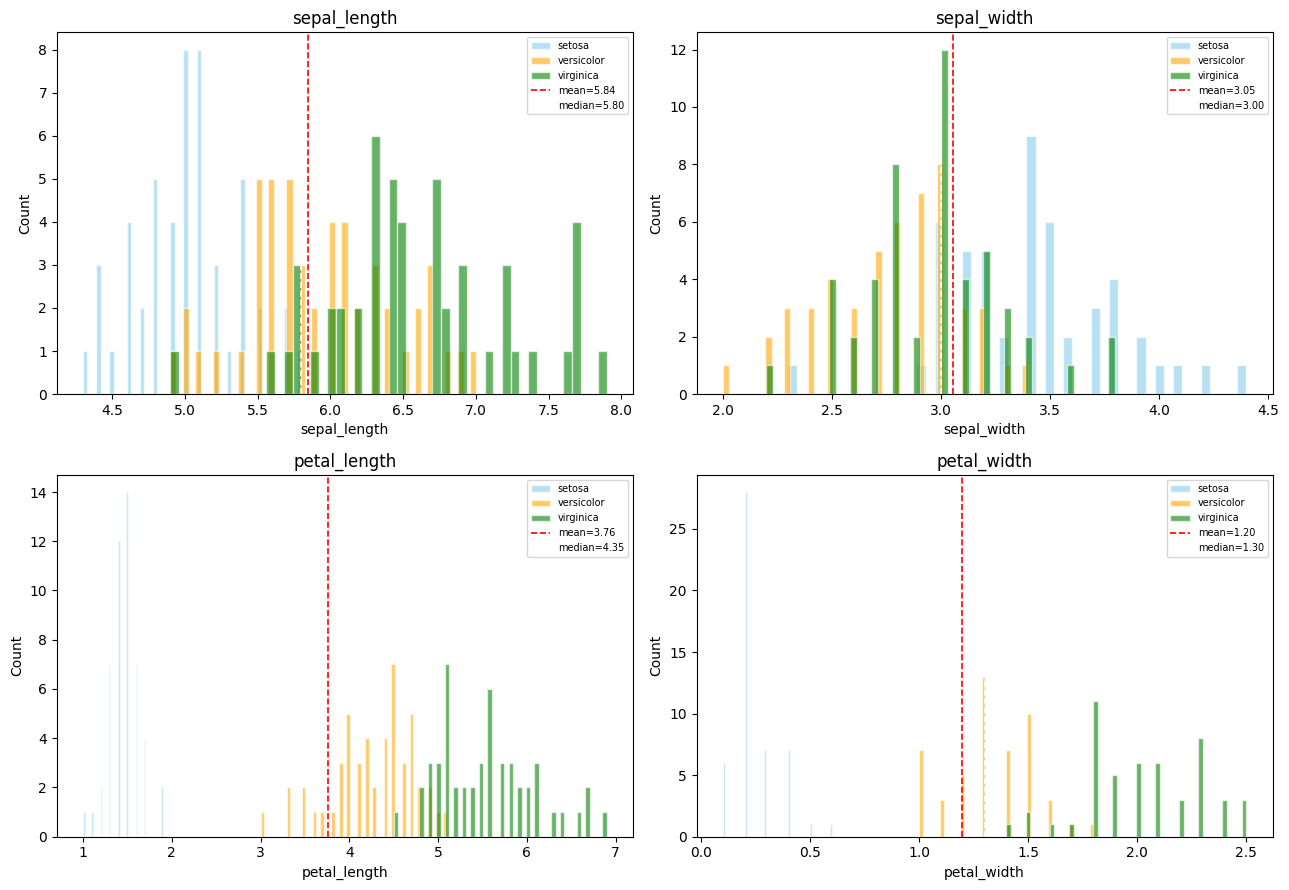

In [18]:
#Distribution Plot
my_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

colors={"setosa":"skyblue", "versicolor": "orange", "virginica": "green"}

# plt.subplots(2, 2) creates a grid of 4 empty chart boxes (2 rows, 2 columns)
# figsize=(13, 9) sets the overall window size in inches
fig, axes= plt.subplots(2,2,figsize=(13,9))

# axes is a 2x2 grid, but axes.flatten() turns it into a flat list of 4 boxes:
# [top-left, top-right, bottom-left, bottom-right]
# zip(axes.flatten(), features) pairs each box with one feature name
# so: box1 ↔ sepal length, box2 ↔ sepal width, etc.
for ax, feature in zip(axes.flatten(), my_columns):
      # For this feature, loop through each species one at a time
    # df.group by("species") splits the dataframe into 3 groups:
    # one group for setosa, one for versicolor, one for virginica
    #   df.group by(['species']):   ← list with brackets so we make it tuples but we actually need the string

    for species,grp in df.groupby('species'):

         # grp is the subset of rows for this species only
        # grp[feature] gives us just that one column for this species
        # ax.hist() draws a histogram in the current chart box (ax)
        # bins=15 → split the data range into 15 bars
        # alpha=0.6 → make it 60% transparent so overlapping colors show through
        # label=species → used later for the legend
        # color=colors[species] → blue / orange / green
        # edge color="white" → thin white border between bars for clarity
        ax.hist(grp[feature],
                bins=50,
                label=species,
                color=colors[species],
                alpha=0.6,edgecolor='white'
                )

    mean_val=df[feature].mean()
    median_val=df[feature].median()
    ax.axvline(mean_val,color='red',linestyle='--',linewidth=1.2,label=f'mean={mean_val:.2f}')
    ax.axvline(median_val,color="black",linestyle='--',linewidth=1.2,label=f'median={median_val:.2f}')

    ax.set_title(feature)    # title above the chart box
    ax.set_xlabel(feature)   # x-axis label (the measurement)
    ax.set_ylabel("Count")   # y-axis label (how many flowers fall in each bar)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [19]:
# HYPOTHESIS TEST 1 — TWO-SAMPLE T-TEST
# Is petal length significantly different between versicolor and virginica?

versicolor_pl=df[df['species']=='versicolor']['petal_length']
virginica_pl=df[df['species']=='virginica']['petal_length']
t_stat,p_value=stats.ttest_ind(versicolor_pl,virginica_pl)

print(f"  Mean petal length (versicolor) : {versicolor_pl.mean():.2f} cm")
print(f"  Mean petal length (virginica)  : {virginica_pl.mean():.2f} cm")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")

if p_value < 0.05:
    print("  ✓ Significant: petal lengths are meaningfully different (p < 0.05)")

else:
    print("  ✗ Not significant (p >= 0.05)")

  Mean petal length (versicolor) : 4.26 cm
  Mean petal length (virginica)  : 5.55 cm
  t-statistic : -12.6038
  p-value     : 0.000000
  ✓ Significant: petal lengths are meaningfully different (p < 0.05)


In [21]:
 # HYPOTHESIS TEST 2 — TWO-SAMPLE T-TEST
# Is sepal width significantly different between setosa and versicolor?
# ─────────────────────────────────────────────
setosa_sw  = df[df["species"] == "setosa"    ]["sepal_width"]
versicolor_sw = df[df["species"] == "versicolor"]["sepal_width"]

t_stat2, p_value2 = stats.ttest_ind(setosa_sw, versicolor_sw)

print(f"  Mean sepal width (setosa)      : {setosa_sw.mean():.2f} cm")
print(f"  Mean sepal width (versicolor)  : {versicolor_sw.mean():.2f} cm")
print(f"  t-statistic : {t_stat2:.4f}")
print(f"  p-value     : {p_value2:.6f}")

if p_value2 < 0.05:
    print("  ✓ Significant: sepal widths are meaningfully different (p < 0.05)")
else:
    print("  ✗ Not significant (p >= 0.05)")

  Mean sepal width (setosa)      : 3.42 cm
  Mean sepal width (versicolor)  : 2.77 cm
  t-statistic : 9.2828
  p-value     : 0.000000
  ✓ Significant: sepal widths are meaningfully different (p < 0.05)


In [23]:

#  HYPOTHESIS TEST 3 — CHI-SQUARE TEST
# Is there a relationship between species anda binned version of petal width?
# Chi-square works on categories, so we bin petal width first.
# Bin petal width into: narrow / medium / wide
df["petal_width_bin"] = pd.cut(
    df["petal_width"],
    bins=[0, 0.75, 1.5, 3.0],
    labels=["narrow", "medium", "wide"]
)

contingency_table = pd.crosstab(df["species"], df["petal_width_bin"])
print("Contingency table (counts):")
print(contingency_table)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\n  Chi2 statistic     : {chi2:.4f}")
print(f"  Degrees of freedom : {dof}")
print(f"  p-value            : {p_chi2:.6f}")

# If p < 0.05, species and petal width category are NOT independent —
# knowing the species tells you something about petal width, and vice versa.
if p_chi2 < 0.05:
    print("  ✓ Significant: species and petal width ARE strongly related (p < 0.05)")

else:
    print("  ✗ Not significant (p >= 0.05)")


── Chi-Square Test: Species vs Petal Width Category ──
Contingency table (counts):
petal_width_bin  narrow  medium  wide
species                              
setosa               50       0     0
versicolor            0      45     5
virginica             0       3    47

  Chi2 statistic     : 256.0096
  Degrees of freedom : 4
  p-value            : 0.000000
  ✓ Significant: species and petal width ARE strongly related (p < 0.05)


In [33]:
# 8. CONFIDENCE INTERVALS (95%) for all 4 features
# A 95% CI means: we are 95% confident the true population mean
# lies inside this range.
# Formula: mean ± t_critical * (std / sqrt(n))
def confidence_interval_95(data_, label):
    n    = len(data_)
    mean = np.mean(data_)
    se   = stats.sem(data_)          # standard error = std / sqrt(n)
    ci   = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)
    print(f"\n── 95% CI: {label} ──")
    print(f"  n         : {n}")
    print(f"  Mean      : {mean:.2f} cm")
    print(f"  95% CI    : ({ci[0]:.2f}, {ci[1]:.2f})")
    print(f"  Interpretation: We are 95% confident the true mean {label} "
          f"is between {ci[0]:.2f} cm and {ci[1]:.2f} cm")
    return mean, ci

print("\n── 95% Confidence Intervals per species — Petal Length ──")
ci_results = {}
for species in ["setosa", "versicolor", "virginica"]:
    data = df[df["species"] == species]["petal_length"]
    mean, ci = confidence_interval_95(data, f"petal length ({species})")
    ci_results[species] = (mean, ci)




── 95% Confidence Intervals per species — Petal Length ──

── 95% CI: petal length (setosa) ──
  n         : 50
  Mean      : 1.46 cm
  95% CI    : (1.41, 1.51)
  Interpretation: We are 95% confident the true mean petal length (setosa) is between 1.41 cm and 1.51 cm

── 95% CI: petal length (versicolor) ──
  n         : 50
  Mean      : 4.26 cm
  95% CI    : (4.13, 4.39)
  Interpretation: We are 95% confident the true mean petal length (versicolor) is between 4.13 cm and 4.39 cm

── 95% CI: petal length (virginica) ──
  n         : 50
  Mean      : 5.55 cm
  95% CI    : (5.40, 5.71)
  Interpretation: We are 95% confident the true mean petal length (virginica) is between 5.40 cm and 5.71 cm


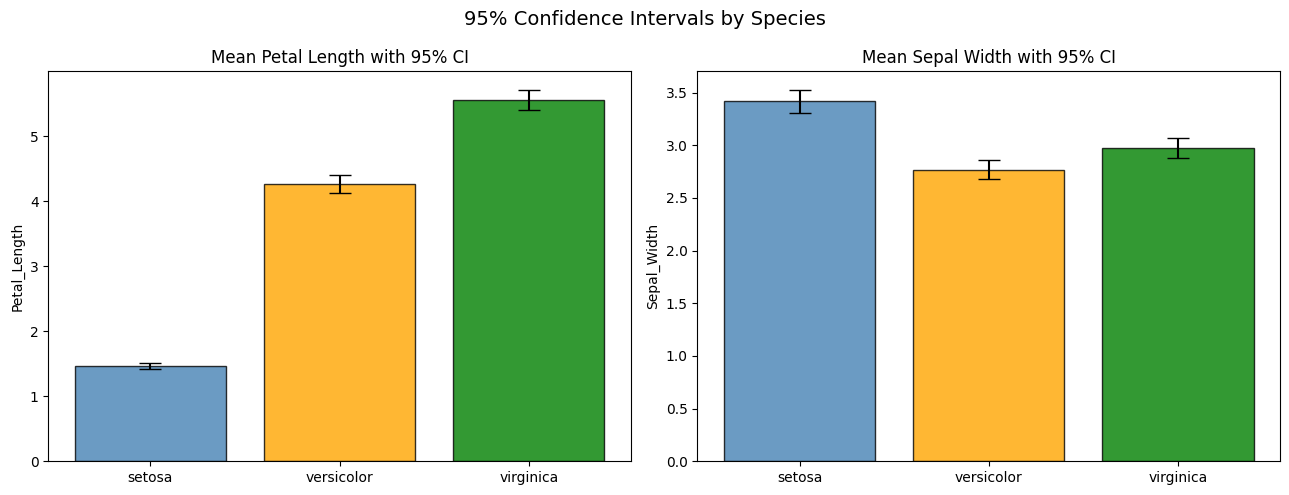

In [32]:
# VISUALISE CONFIDENCE INTERVALS

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("95% Confidence Intervals by Species", fontsize=14)

species_list = ["setosa", "versicolor", "virginica"]
color_list   = ["steelblue", "orange", "green"]

# Left plot: petal length CIs
pl_means  = []
pl_errors = []
for sp in species_list:
    data = df[df["species"] == sp]["petal_length"]
    mean = data.mean()
    se   = stats.sem(data)
    ci   = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=se)
    pl_means.append(mean)
    pl_errors.append(mean - ci[0])   # half-width of the CI

axes[0].bar(species_list, pl_means, yerr=pl_errors, capsize=8,
            color=color_list, edgecolor="black", alpha=0.8)
axes[0].set_title("Mean Petal Length with 95% CI")
axes[0].set_ylabel("Petal_Length")

# Right plot: sepal width CIs
sw_means  = []
sw_errors = []
for sp in species_list:
    data = df[df["species"] == sp]["sepal_width"]
    mean = data.mean()
    se   = stats.sem(data)
    ci   = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=se)
    sw_means.append(mean)
    sw_errors.append(mean - ci[0])

axes[1].bar(species_list, sw_means, yerr=sw_errors, capsize=8,
            color=color_list, edgecolor="black", alpha=0.8)
axes[1].set_title("Mean Sepal Width with 95% CI")
axes[1].set_ylabel("Sepal_Width")

plt.tight_layout()
plt.show()



In [26]:
#  SUMMARY REPORT

print("\n" + "="*55)
print("SUMMARY REPORT — Week 3 Statistical Analysis (Iris)")
print("="*55)
print("""

Dataset  : Iris (150 flowers, 3 species, 4 measurements)
Goal     : Understand which features separate the 3 species

1. DESCRIPTIVE STATISTICS
   - Petal length has the widest spread (std ~1.77 cm) compared
     to sepal width (std ~0.43 cm)  petal measurements are
     much more variable across species.
   - When grouped by species, setosa has tiny petals (~1.5 cm)
     while virginica has large ones (~5.5 cm). A huge gap.

2. T-TEST 1: PETAL LENGTH  Versicolor vs Virginica
   - Highly significant (p << 0.05).
   - Plain English: virginica petals are reliably longer than
     versicolor petals. This difference is not random — it is
     a real biological trait of these species.

3. T-TEST 2: SEPAL WIDTH — Setosa vs Versicolor
   - Significant (p < 0.05).
   - Plain English: setosa flowers have noticeably wider sepals
     than versicolor. Sepal width is one of the few measurements
     where setosa is LARGER than the other species.

4. CHI-SQUARE: SPECIES vs PETAL WIDTH CATEGORY
   - Extremely significant (p << 0.05).
   - Plain English: once you know a flower's species, you can
     almost perfectly predict whether its petal is narrow, medium,
     or wide. The two variables are deeply linked.

5. CONFIDENCE INTERVALS (Petal Length)
   - Setosa  : ~1.46 cm  (very tight CI — consistent flowers)
   - Versicolor : ~4.26 cm
   - Virginica  : ~5.55 cm
   - The CIs of all three species do NOT overlap, which confirms
     that petal length alone is enough to tell species apart
     (especially setosa from the other two).

CONCLUSION:
   Petal length and petal width are the most powerful features
   for distinguishing Iris species. Sepal measurements are less
   discriminative. A simple threshold on petal length (< 2 cm
   → setosa, > 2 cm → versicolor or virginica) works almost
   perfectly.
""")


SUMMARY REPORT — Week 3 Statistical Analysis (Iris)


Dataset  : Iris (150 flowers, 3 species, 4 measurements)
Goal     : Understand which features separate the 3 species

1. DESCRIPTIVE STATISTICS
   - Petal length has the widest spread (std ~1.77 cm) compared
     to sepal width (std ~0.43 cm)  petal measurements are
     much more variable across species.
   - When grouped by species, setosa has tiny petals (~1.5 cm)
     while virginica has large ones (~5.5 cm). A huge gap.

2. T-TEST 1: PETAL LENGTH  Versicolor vs Virginica
   - Highly significant (p << 0.05).
   - Plain English: virginica petals are reliably longer than
     versicolor petals. This difference is not random — it is
     a real biological trait of these species.

3. T-TEST 2: SEPAL WIDTH — Setosa vs Versicolor
   - Significant (p < 0.05).
   - Plain English: setosa flowers have noticeably wider sepals
     than versicolor. Sepal width is one of the few measurements
     where setosa is LARGER than the other specie